In [1]:
import os 
from glob import glob
from functools import reduce

import numpy as np
import jax.numpy as jnp

import xarray as xr
import pandas as pd
import dask

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.crs as ccrs
from matplotlib.lines import Line2D
from matplotlib.colors import LinearSegmentedColormap
import cartopy.feature as cfeature
import nc_time_axis
import cftime

from utils.parallel_axis import custom_parallel_coordinates
from utils.param_names import param_names
from utils.param_bounds import params_lower, params_upper
from utils.initial_params import constants, initial_params
from utils.global_paths import project_data_path, project_code_path
from utils.subsets import subsets
from utils.constants import obs_colors, location_names, location_coords, obs_names, obs_names_plot
from utils.construct_Kpet import construct_Kpet_map
from read_inputs import read_hindcast_inputs
from data_processing import _subset_states
from prediction import make_prediction_vmap

cm_data = np.loadtxt("../src/utils/colormaps/lapaz.txt")
sc_cmap = LinearSegmentedColormap.from_list("cmap", cm_data, N=10)

In [2]:
# Set fonts
from matplotlib import font_manager
font_dirs = ["/storage/home/dcl5300/fonts"]

font_files = font_manager.findSystemFonts(fontpaths=font_dirs)

for font_file in font_files:
    font_manager.fontManager.addfont(font_file)
    
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = "Arial"
plt.rcParams['text.usetex'] = False
plt.rcParams["font.size"] = 12
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["axes.linewidth"] = 1.50

In [3]:
# ############
# ### Dask ###
# ############
# from dask_jobqueue import SLURMCluster

# cluster = SLURMCluster(
#     account="pches_cr_default",
#     queue='basic',
#     # account="open",
#     cores=1,
#     memory="20GiB",
#     walltime="01:00:00"
# )
# cluster.scale(jobs=10)  # ask for jobs

# from dask.distributed import Client
# client = Client(cluster)
# client

## Preliminaries

In [4]:
def get_training_res(subset_name, obs_name, loss_metric, metrics_include, best_metric):
    """
    Reads the training results
    """
    # Loop through files
    files = glob(f'{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/training_res/*.txt')

    df_out = []
    for file in files:
        # Read
        df = pd.read_csv(file, sep = ' ').dropna(how='any')
        df['epoch'] = df['epoch'].astype(np.float32)

        # Add identifiers
        _, param_id, val_id, _ = file.split('/')[-1].split('_')
        df['param_id'] = param_id
        df['val_id'] = val_id
        
        # Take best
        df_best = df.query('epoch > 10').sort_values(by=loss_metric).iloc[:1]
        if len(df_best) > 0:
            df_out.append(df_best)

    # Join
    df_out = pd.concat(df_out).reset_index().drop(columns='index')

    # Filter best result for each metric
    if best_metric:
        df_out = df_out.sort_values(loss_metric).drop_duplicates('metric')

    # Subset metrics 
    if metrics_include != 'all':
        df_out = df_out[df_out['metric'].isin(metrics_include)]

    # Return
    return df_out

In [5]:
def simulate_hindcast(subset_name, obs_name, theta):
    """
    Simulates soil moisture from given parameter set
    """
    
    # Get simulation output
    ys, x_forcing_nt, x_forcing_nyrs, x_maps = read_hindcast_inputs(subset_name, obs_name, False)

    out = make_prediction_vmap(
        theta,
        constants,
        x_forcing_nt,
        x_forcing_nyrs,
        x_maps
        )

    # Construct xr 
    nldas_lats = np.load(f"{project_code_path}/code/utils/grids/{subset_name}_lat.npy")
    nldas_lons = np.load(f"{project_code_path}/code/utils/grids/{subset_name}_lon.npy")
    nt = out.shape[1]

    ds_sim = xr.Dataset(
        data_vars=dict(soilMoist=(["time", "lat", "lon"], np.transpose(out.reshape(len(nldas_lons), len(nldas_lats), nt), (2,1,0)))),
        coords=dict(
            lon=nldas_lons,
            lat=nldas_lats,
            time=xr.cftime_range(start='2016-01-01', end='2022-12-31', calendar='365_day')))

    return ds_sim

## Get hindcasts and calibration statistics

In [6]:
metrics_include = ['kge', 'nse', 'taylor',
                   'rmse', 'ubrmse',
                   'mae', 'ubmae', 
                   'mse', 'ubmse',
                   'outer20rmse', 'outer20ubrmse',
                   'outer50rmse', 'outer50ubrmse']

### Hindcasts

In [6]:
# Add identifiers and store
def store_sim(ds_sim, mask, subset_name, obs_name, sim_id, save_dir):
    # Use 100 as threshold for NaNs outside mask
    if ds_sim['soilMoist'].isnull().any(dim='time').where(mask).sum() > 100.:
        print(f'NaNs found in {obs_name} {sim_id}')
        return None
    
    # Store
    ds_sim = ds_sim.assign_coords(sim_id=sim_id)
    ds_sim.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/{sim_id}.nc",
                     encoding = {"soilMoist": {"zlib": True, "complevel": 2}})

In [14]:
%%time
################
# DASK
################
# Simulate all outputs to make reading easier
subset_name = 'eCONUS'
loss_metric = 'pred_loss'

best_metric = True
save_dir = 'best_only'

delayed = []

for obs_name in obs_names:
    # Get mask
    ds_obs = xr.open_dataset(f'{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc')
    mask = ~ds_obs['soilMoist'].isnull().any(dim='time')
    
    # Loop through results
    df_res = get_training_res(subset_name, obs_name, loss_metric, metrics_include, best_metric)
    for idr in range(len(df_res)):
        
        # Identifiers
        sim_id = f"{df_res.iloc[idr]['metric']}_{df_res.iloc[idr]['param_id']}_{df_res.iloc[idr]['val_id']}"
        file = f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/{sim_id}.nc"
        
        # Check if done
        if not os.path.exists(file):
            # Get theta
            theta = jnp.array([df_res.iloc[idr][param] for param in param_names])
            # Simulate
            ds_sim = dask.delayed(simulate_hindcast)(subset_name, obs_name, theta)
            # Store
            delayed.append(dask.delayed(store_sim)(ds_sim, mask, subset_name, obs_name, sim_id, save_dir))

# Compute
print(len(delayed))
_ = dask.compute(*delayed)

52
CPU times: user 19.1 s, sys: 3.13 s, total: 22.2 s
Wall time: 3min 22s


### Single prediction statistics

In [24]:
##################################
# All calibration statistics
# we might be interested in
##################################

def _pearson_r(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    r = xr.corr(ds, ds_obs, dim='time')
    ds_r = xr.Dataset({"pearson":r})
    ds_r.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/pearson_{save_name}.nc")
    
def _rmse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    rmse = np.sqrt(((ds - ds_obs)**2).mean(dim="time"))
    ds_rmse = xr.Dataset({"rmse":rmse})
    ds_rmse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/rmse_{save_name}.nc")

def _ubrmse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    ds_centered = ds - ds.mean(dim='time')
    ds_obs_centered = ds_obs - ds_obs.mean(dim='time')
    ubrmse = np.sqrt(((ds_centered - ds_obs_centered)**2).mean(dim="time"))
    ds_ubrmse = xr.Dataset({"ubrmse":ubrmse})
    ds_ubrmse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/ubrmse_{save_name}.nc")

def _nse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    nse = 1 - ((ds_obs - ds) ** 2).sum(dim="time") / ((ds_obs - ds_obs.mean(dim="time")) ** 2).sum(dim="time")
    ds_nse = xr.Dataset({"nse":nse})
    ds_nse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/nse_{save_name}.nc")

def _kge(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    corr = xr.corr(ds, ds_obs, dim="time")
    mean_ratio = ds.mean(dim="time")/ds_obs.mean(dim="time")
    std_ratio = ds.std(dim="time")/ds_obs.std(dim="time")
    kge = 1 - np.sqrt((corr - 1) ** 2 + (mean_ratio - 1) ** 2 + (std_ratio - 1) ** 2)
    ds_kge = xr.Dataset({"kge":kge})
    ds_kge.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/kge_{save_name}.nc")

def _ac(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    ds_centered = ds - ds.mean(dim='time')
    ds_obs_centered = ds_obs - ds_obs.mean(dim='time')
    ac = xr.corr(ds_centered, ds_obs_centered, dim="time")
    ds_ac = xr.Dataset({"ac":ac})
    ds_ac.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/ac_{save_name}.nc")

def _taylor(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    corr = xr.corr(ds, ds_obs, dim="time")
    std_ratio = ds.std(dim="time")/ds_obs.std(dim="time")
    R0 = 1.0
    taylor = 4 * (1 + corr) / (((std_ratio + 1 / std_ratio) ** 2) * (1 + R0))
    ds_taylor = xr.Dataset({"taylor":taylor})
    ds_taylor.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/taylor_{save_name}.nc")

def _mse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    mse = ((ds - ds_obs)**2).mean(dim="time")
    ds_mse = xr.Dataset({"mse":mse})
    ds_mse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/mse_{save_name}.nc")

def _mae(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    mae = (np.abs(ds - ds_obs)).mean(dim="time")
    ds_mae = xr.Dataset({"mae":mae})
    ds_mae.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/mae_{save_name}.nc")

def _outer50rmse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    inds = (ds_obs <= ds_obs.quantile(0.25, dim='time')) | (ds_obs >= ds_obs.quantile(0.75, dim='time'))
    outer50rmse = np.sqrt(((ds.where(inds) - ds_obs.where(inds))**2).mean(dim="time"))
    ds_outer50rmse = xr.Dataset({"outer50rmse":outer50rmse})
    ds_outer50rmse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/outer50rmse_{save_name}.nc")

def _outer20rmse(ds, ds_obs, save_name, subset_name, obs_name, save_dir):
    inds = (ds_obs <= ds_obs.quantile(0.1, dim='time')) | (ds_obs >= ds_obs.quantile(0.9, dim='time'))
    outer20rmse = np.sqrt(((ds.where(inds) - ds_obs.where(inds))**2).mean(dim="time"))
    ds_outer20rmse = xr.Dataset({"outer20rmse":outer20rmse})
    ds_outer20rmse.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{save_dir}/stats/outer20rmse_{save_name}.nc")

In [25]:
# List
stat_funcs = {'pearson':_pearson_r,
              'rmse':_rmse,
              'mse':_mse,
              'mae':_mae,
              'kge':_kge,
              'ubrmse':_ubrmse,
              'nse':_nse,
              'taylor':_taylor,
              'outer50rmse':_outer50rmse,
              'outer20rmse':_outer20rmse}

In [26]:
#############################################
# Calculate calibration stats for hindcasts
#############################################
def get_calibration_stats(subset_name, obs_name, stats, hindcast_dir, save_name):
    # Read all sims
    files = glob(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/*.nc")
    files = [file for file in files if file.split('/')[-1].split('_')[0] in metrics_include]
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='sim_id')
    ds['sim_id'].encoding["dtype"] = "S1"
    ds = ds['soilMoist'].chunk({'lat':-1, 'lon':-1}).persist()
        
    # Read obs
    ds_obs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc")['soilMoist']

    # Calculate desired stats
    for stat in stats:
        if not os.path.exists(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/{stat}_{save_name}.nc"):
            stat_func = stat_funcs[stat]
            stat_func(ds, ds_obs, save_name, subset_name, obs_name, hindcast_dir)

In [27]:
%%time

subset_name = "eCONUS"
hindcast_dir = "best_only"
save_name = "best_only"
stats = ["rmse", "mse", "mae", "kge", "nse", "taylor", "outer50rmse", "outer20rmse", "ubrmse", "pearson"]

for obs_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
    get_calibration_stats(subset_name=subset_name,
                          obs_name=obs_name,
                          stats=stats,
                          hindcast_dir=hindcast_dir,
                          save_name=save_name)

/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 1.32 GiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/distributed/client.py:3371: UserWarning: Sending large graph of size 749.46 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(
/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-pac

CPU times: user 27.4 s, sys: 8.8 s, total: 36.2 s
Wall time: 1min 48s


In [28]:
#############################################
# Calculate calibration stats for obs-obs
#############################################
def get_pairwise_stats(subset_name, obs_1_name, obs_2_name, stats):
    # Read obs
    ds_obs1 = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_1_name}/{obs_1_name}_validation.nc")['soilMoist']
    ds_obs2 = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_2_name}/{obs_2_name}_validation.nc")['soilMoist']

    # Calculate desired stats
    for stat in stats:
        if not os.path.exists(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_1_name}/hindcasts/other_obs/stats/{stat}_{obs_2_name}.nc"):
            stat_func = stat_funcs[stat]
            stat_func(ds_obs1, ds_obs2, obs_2_name, subset_name, obs_1_name, 'other_obs')

In [29]:
%%time
subset_name = "eCONUS"
stats = ["rmse", "mse", "mae", "kge", "nse", "taylor", "outer50rmse", "outer20rmse", "ubrmse", "pearson"]

for obs_1_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
    for obs_2_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
        if obs_1_name != obs_2_name:
            get_pairwise_stats(subset_name=subset_name,
                               obs_1_name=obs_1_name,
                               obs_2_name=obs_2_name,
                               stats=stats)

/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/work/dcl5300/curren

CPU times: user 1min 10s, sys: 31.6 s, total: 1min 42s
Wall time: 1min 51s


/storage/work/dcl5300/current_projects/wbm_soilM_uc_2024/.venv/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


### Ensemble statistics

In [7]:
def _crps(ds, ds_obs, save_name, subset_name, obs_name, hindcast_dir):
    crps = xs.crps_ensemble(observations=ds_obs,
                                       forecasts=ds.chunk(dict(sim_id=-1)),
                                       member_dim='sim_id',
                                       dim='time')
    ds_crps = xr.Dataset({"crps":crps})
    ds_crps.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/crps_{save_name}.nc")

def _coverage(ds, ds_obs, save_name, subset_name, obs_name, hindcast_dir):
    # Get max/mins
    ds_maxs = ds.max(dim="sim_id")
    ds_mins = ds.min(dim="sim_id")
    
    # Get coverage
    ds_above = ds_obs > ds_maxs
    ds_below = ds_obs < ds_mins
    coverage = 100 * (1. - (ds_above + ds_below)).mean(dim="time")
    
    # Save
    ds_mins.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/mins_{save_name}.nc",
                     encoding = {"soilMoist": {"zlib": True, "complevel": 2}})
    ds_maxs.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/maxs_{save_name}.nc",
                     encoding = {"soilMoist": {"zlib": True, "complevel": 2}})
    
    ds_coverage = xr.Dataset({'coverage':coverage.where(~ds_maxs.isel(time=1).isnull())})
    ds_coverage.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/coverage_{save_name}.nc")

def _ubcoverage(ds, ds_obs, save_name, subset_name, obs_name, hindcast_dir):
    # Center
    ds_centered = ds - ds.mean(dim='time')
    ds_obs_centered = ds_obs - ds_obs.mean(dim='time')
    
    # Get max/mins
    ds_maxs = ds_centered.max(dim="sim_id")
    ds_mins = ds_centered.min(dim="sim_id")
    
    # Get coverage
    ds_above = ds_obs_centered > ds_maxs
    ds_below = ds_obs_centered < ds_mins
    coverage = 100 * (1. - (ds_above + ds_below)).mean(dim="time")
    
    # Save
    ds_mins.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/centered_mins_{save_name}.nc",
                     encoding = {"soilMoist": {"zlib": True, "complevel": 2}})
    ds_maxs.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/centered_maxs_{save_name}.nc",
                     encoding = {"soilMoist": {"zlib": True, "complevel": 2}})
    
    ds_coverage = xr.Dataset({'coverage':coverage.where(~ds_maxs.isel(time=1).isnull())})
    ds_coverage.to_netcdf(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/ubcoverage_{save_name}.nc")


In [8]:
# List
stat_funcs = {'coverage':_coverage}

In [9]:
#############################################
# Calculate calibration stats for hindcasts
#############################################
def get_calibration_stats(subset_name, obs_name, stats, metrics_include, save_name, hindcast_dir):
    # Read all sims
    files = glob(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/*.nc")
    files = [file for file in files if file.split('/')[-1].split('_')[0] in metrics_include]
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='sim_id')
    ds['sim_id'].encoding["dtype"] = "S1"
    ds = ds['soilMoist'].chunk({'lat':-1, 'lon':-1}).persist()
        
    # Read obs
    ds_obs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc")['soilMoist']

    # Calculate desired stats
    for stat in stats:
        if not os.path.exists(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/{stat}_{save_name}.nc"):
            stat_func = stat_funcs[stat]
            stat_func(ds, ds_obs, save_name, subset_name, obs_name, hindcast_dir)

In [10]:
%%time

subset_name = "eCONUS"
hindcast_dir = "best_only"

save_name = "best_only"
stats = ["coverage"]

for obs_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
    get_calibration_stats(subset_name=subset_name,
                          obs_name=obs_name,
                          stats=stats,
                          metrics_include=metrics_include,
                          hindcast_dir=hindcast_dir,
                          save_name=save_name)

/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 1.17 GiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 599.40 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of size 599.40 MiB.
This may cause some slowdown.
Consider scattering data ahead of time and using futures.
  warnings.warn(
/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/distributed/client.py:3162: UserWarning: Sending large graph of 

CPU times: user 41.7 s, sys: 16 s, total: 57.7 s
Wall time: 3min


In [28]:
%%time
#########################################
# Full coverage: separate calculation
#########################################
subset_name = "eCONUS"
hindcast_dir = "best_only"
save_name = "best_only"

# Read all sims
ds_all = []
for obs_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
    files = glob(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/*.nc")
    files = [file for file in files if file.split('/')[-1].split('_')[0] in metrics_include]
    ds = xr.open_mfdataset(files, combine='nested', concat_dim='sim_id')
    ds['sim_id'].encoding["dtype"] = "S1"
    ds = ds['soilMoist'].chunk({'lat':-1, 'lon':-1})
    ds = ds.assign_coords(obs_name = obs_name)
    ds_all.append(ds)

ds_all = xr.concat(ds_all, dim='obs_name')

# Get all obs
ds_obs_all = []
for obs_name in ["SMAP", "VIC", "NOAH", "MOSAIC"]:
    ds_obs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc", chunks='auto')
    ds_obs = ds_obs.assign_coords(obs_name = obs_name)
    ds_obs_all.append(ds_obs)

ds_obs_all = xr.concat(ds_obs_all, dim='obs_name')['soilMoist']

# Center
ds_centered = ds_all - ds_all.mean(dim='time')
ds_obs_centered = ds_obs_all - ds_obs_all.mean(dim='time')

# Get max/mins
ds_maxs = ds_centered.max(dim=["sim_id", "obs_name"])
ds_mins = ds_centered.min(dim=["sim_id", "obs_name"])

# Save
xr.Dataset({'soilMoist':ds_mins}).to_netcdf(f"{project_data_path}/WBM/calibration/combined/{subset_name}/centered_mins_{combined}_{save_name}.nc",
                                           encoding = {"soilMoist": {"zlib": True, "complevel": 2}})
xr.Dataset({'soilMoist':ds_maxs}).to_netcdf(f"{project_data_path}/WBM/calibration/combined/{subset_name}/centered_maxs_{combined}_{save_name}.nc",
                                           encoding = {"soilMoist": {"zlib": True, "complevel": 2}})

# Get coverage
ds_above = ds_obs_centered > ds_maxs
ds_below = ds_obs_centered < ds_mins
coverage = 100 * (1. - (ds_above + ds_below)).mean(dim=['time', 'obs_name'])

# Store
ds_coverage = xr.Dataset({'coverage':coverage})
ds_coverage.to_netcdf(f"{project_data_path}/WBM/calibration/combined/{subset_name}/ubcoverage_{combined}_{save_name}.nc")

/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': True}):
    ...     array[indexer]
  return self.array[key]
/storage/home/dcl5300/miniforge3/envs/climate-stack-mamba-2023-12/lib/python3.11/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing is producing a large chunk. To accept the large
chunk and silence this warning, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunks': False}):
    ...     array[indexer]

To avoid creating the large chunks, set the option
    >>> with dask.config.set(**{'array.slicing.split_large_chunk

# Plots

## Parallel axis

In [122]:
stats_to_include = ["rmse", "mse", "mae", "kge", "nse", "taylor", "outer50rmse", "outer20rmse"]

minmaxs = {"rmse":"min",
           "mse":"min",
           "mae":"min",
           "kge":"max",
           "nse":"max",
           "ac":"max",
           "taylor":"max",
           "outer50rmse":"min",
           "outer20rmse":"min",
           "ubrmse":"min",}

error_fn_names = [
    "rmse",
    "mse",
    "mae",
    "kge",
    "nse",
    "taylor",
    "outer50rmse",
    "outer20rmse",
]

color_dict_categorical = {stat:f"C{ids}" for ids, stat in enumerate(error_fn_names)}

for metric in metrics_include:
    if metric not in color_dict_categorical.keys():
        color_dict_categorical[metric] = 'black'

In [23]:
def parallel_axis_plot(subset_name, obs_name, save_name, stats_to_include):
    # Read all
    df_all = []

    for stat in stats_to_include: 
        df_stat = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/best_only/stats/{stat}_{save_name}.nc").mean(dim=['lat','lon']).to_dataframe().reset_index()[['sim_id', stat]]
        df_all.append(df_stat)

    # Merge all
    df_all = reduce(lambda left,right: pd.merge(left, right, on='sim_id', how='inner'), df_all)
    df_all['loss_id'] = df_all['sim_id'].apply(lambda x: x.split('_')[0])

    # Plot
    custom_parallel_coordinates(df_all, columns_axes=stats_to_include,
                            axis_labels = stats_to_include, 
                            zorder_by=0, ideal_direction='top',
                            alpha_base=1.0, lw_base=2, fontsize=12, figsize=(14,8),
                            minmaxs=[minmaxs[stat] for stat in stats_to_include], 
                            color_by_categorical = 'loss_id',
                            color_dict_categorical=color_dict_categorical)

In [25]:
# parallel_axis_plot('eCONUS', 'VIC', 'best_only', stats_to_include)

## Fit results

In [7]:
minmaxs = {"rmse":"min",
           "mse":"min",
           "mae":"min",
           "kge":"max",
           "nse":"max",
           "ac":"max",
           "taylor":"max",
           "outer50rmse":"min",
           "outer20rmse":"min",
           "ubrmse":"min",
           "pearson":"max"}

def plot_hist_stat_all(subset_name, stat_name, hindcast_dir, save_name, legend_loc, xlabel, xlims, show_other_obs, axs):
    
    for ido, obs_name in enumerate(obs_names):
        ds_stat = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/{stat_name}_{save_name}.nc")
        ax = axs[ido]
        # Loop through all sims
        for id in range(len(ds_stat.sim_id)):
            data = ds_stat.isel(sim_id=id)[stat_name].to_numpy().flatten()
            data = data[~np.isnan(data)]
            ax.ecdf(data, color='silver', alpha=0.5)
        # Plot best
        if minmaxs[stat_name] == "max":
            arg_best = ds_stat[stat_name].mean(dim=['lat','lon']).argmax(dim='sim_id')
        else:
            arg_best = ds_stat[stat_name].mean(dim=['lat','lon']).argmin(dim='sim_id')
        data = ds_stat.isel(sim_id = arg_best)[stat_name].to_numpy().flatten()
        data = data[~np.isnan(data)]
        ax.ecdf(data, color='black', lw=lw, label='Best sim.')

        # Other obs
        if show_other_obs:
            for other_obs_name in obs_names:
                if other_obs_name != obs_name:
                    ds_stat = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/other_obs/stats/{stat_name}_{other_obs_name}.nc")
                    data = ds_stat[stat_name].to_numpy().flatten()
                    data = data[~np.isnan(data)]
                    ax.ecdf(data, color=obs_colors[other_obs_name], label=other_obs_name, lw=lw)
    
        # Tidy
        # if ido in [2,3]:
        ax.set_xlabel(f'{xlabel}')
        if ido == 0:
            # if ido in [0,2]:
            ax.set_ylabel('CDF')
        ax.set_yticks(np.arange(0.,1.01,0.25), ['0','','','','1'])
        if xlims:
            ax.set_xlim(xlims)
        if legend_loc:
            ax.legend(loc=legend_loc)
        ax.grid()
        ax.set_title(obs_names_plot[obs_name])

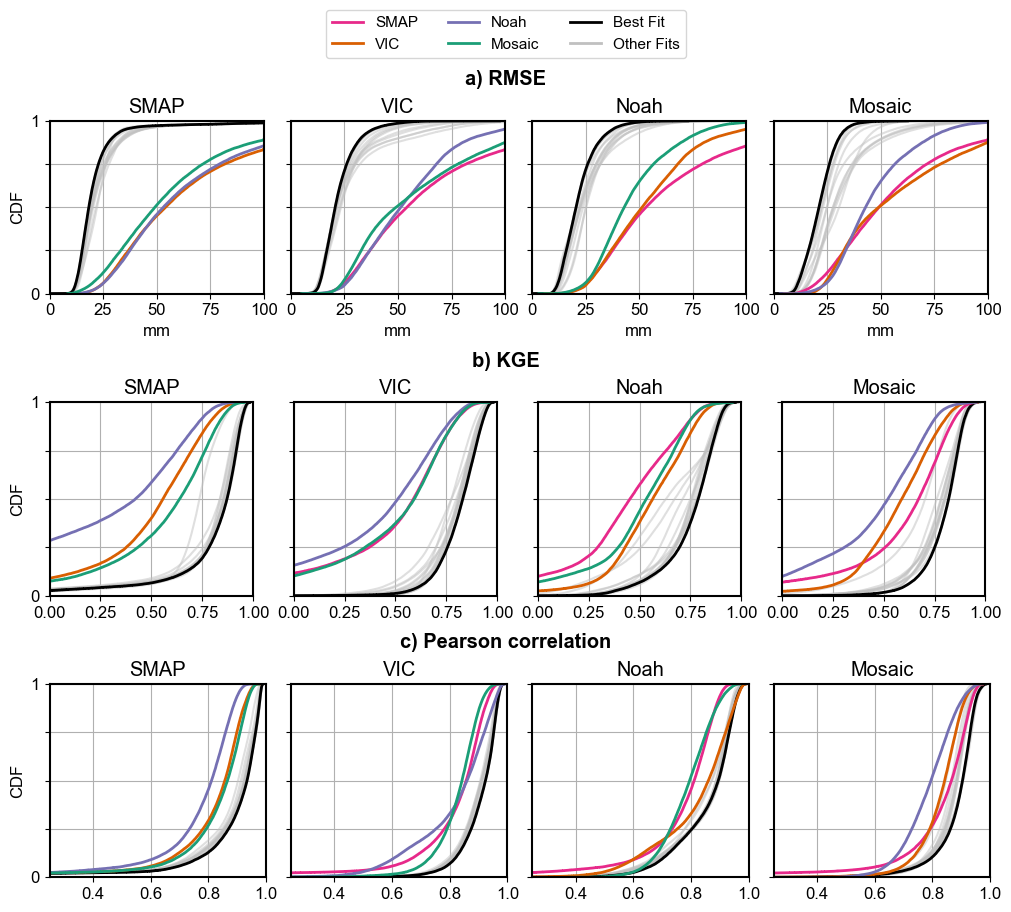

In [8]:
subset_name = 'eCONUS'
save_name = "best_only"
hindcast_dir = "best_only"
lw=2

fig = plt.figure(layout='constrained', figsize=(10, 9))
subfigs = fig.subfigures(4, 1, wspace=0.07, height_ratios = [2,10,10,10])

# Add legend
axsLegend = subfigs[0].subplots()

custom_lines = [Line2D([0], [0], color=obs_colors['SMAP'], lw=lw),
                Line2D([0], [0], color=obs_colors['VIC'], lw=lw),
                Line2D([0], [0], color=obs_colors['NOAH'], lw=lw),
                Line2D([0], [0], color=obs_colors['MOSAIC'], lw=lw),
                Line2D([0], [0], color='black', lw=lw),
                Line2D([0], [0], color='silver', lw=lw)]
axsLegend.legend(custom_lines, ['SMAP', 'VIC', 'Noah', 'Mosaic', 'Best Fit', 'Other Fits'],
                ncols=3, fontsize=11, loc='center')
axsLegend.axis('off')

# axsTop = subfigs[1].subplots(2, 2, sharey=True, sharex=True)
axsTop = subfigs[1].subplots(1, 4, sharey=True, sharex=True)
subfigs[1].suptitle('a) RMSE', fontweight='bold')

# axsMiddle = subfigs[2].subplots(2, 2, sharey=True, sharex=True)
axsMiddle = subfigs[2].subplots(1, 4, sharey=True, sharex=True)
subfigs[2].suptitle('b) KGE', fontweight='bold')

# axsBottom = subfigs[3].subplots(2, 2, sharey=True, sharex=True)
axsBottom = subfigs[3].subplots(1, 4, sharey=True, sharex=True)
subfigs[3].suptitle('c) Pearson correlation', fontweight='bold')

##############
# RMSE
##############
stat_name = "rmse"
xlabel = "mm"
legend_loc = False

plot_hist_stat_all(subset_name=subset_name,
                   stat_name=stat_name,
                   hindcast_dir=hindcast_dir,
                   save_name=save_name,
                   legend_loc=legend_loc,
                   xlabel=xlabel,
                   xlims=[0,100],
                   show_other_obs=True,
                   axs=axsTop.flatten())

##############
# ubRMSE
##############
stat_name = "kge"
xlabel = ""
legend_loc = False

plot_hist_stat_all(subset_name=subset_name,
                   stat_name=stat_name,
                   hindcast_dir=hindcast_dir,
                   save_name=save_name,
                   legend_loc=legend_loc,
                   xlabel=xlabel,
                   xlims=[0,1],
                   show_other_obs=True,
                   axs=axsMiddle.flatten())

##############
# KGE
##############
stat_name = "pearson"
xlabel = ""
legend_loc = False

plot_hist_stat_all(subset_name=subset_name,
                   stat_name=stat_name,
                   hindcast_dir=hindcast_dir,
                   save_name=save_name,
                   legend_loc=legend_loc,
                   xlabel=xlabel,
                   xlims=[0.25,1],
                   show_other_obs=True,
                   axs=axsBottom.flatten())

plt.savefig('../figs/main/fig4_calibration_ecdfs.pdf', bbox_inches = 'tight')

## Coverage

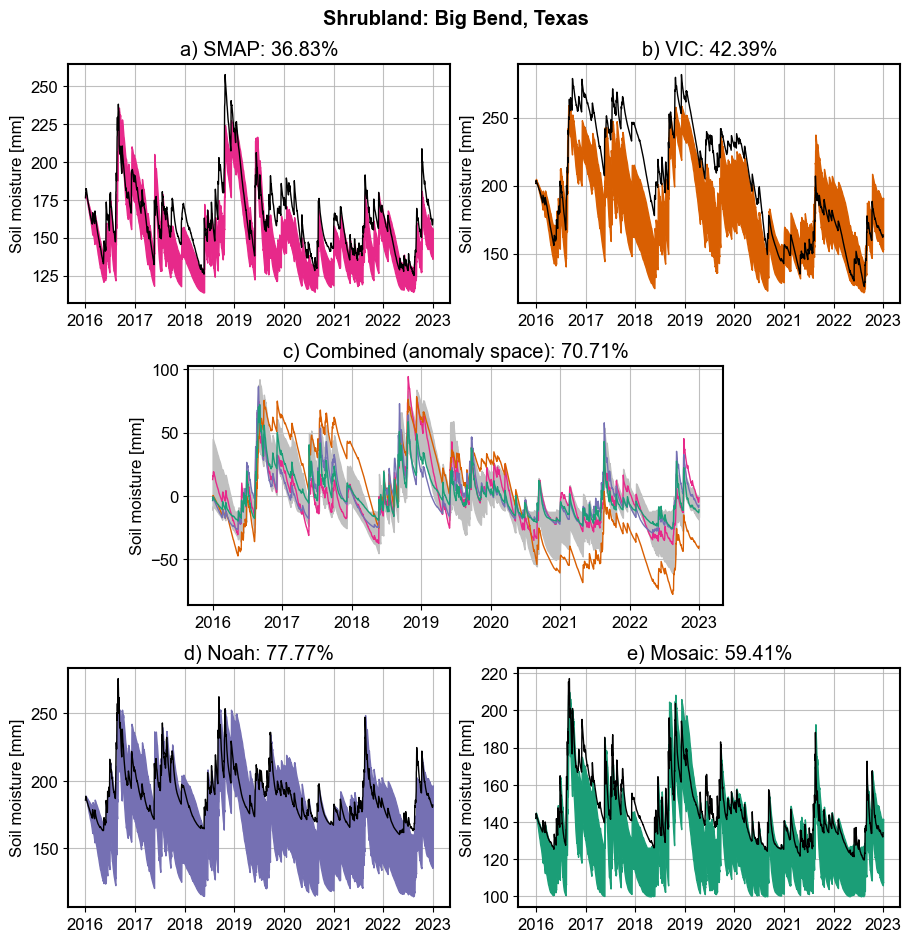

In [9]:
#################
# TIMESERIES PLOT
#################
subset_name = 'eCONUS'
save_name = 'best_only'
hindcast_dir = 'best_only'

location = 'bigbend'
lat, lon = location_coords[location]
# save_str = '../figs/main/fig5_mclean_coverage.pdf'
save_str = f'../figs/si/{location}_coverage.pdf'

fig = plt.figure(layout='constrained', figsize=(9, 9))
subfigs = fig.subfigures(3, 1, wspace=0.01)

fig.suptitle(location_names[location], fontweight='bold', y=1.03)

axsTop = subfigs[0].subplots(1, 2, sharex=True, sharey=False,
                              gridspec_kw=dict(wspace=0.02, hspace=0.02))
axsTop = axsTop.flatten()

axsBottom = subfigs[2].subplots(1, 2, sharex=True, sharey=False,
                              gridspec_kw=dict(wspace=0.02, hspace=0.02))
axsBottom = axsBottom.flatten()

axMiddle = subfigs[1].subplots()
axMiddle.axis('off')
axMiddleins = axMiddle.inset_axes(bounds=[0.2, 0.0, 0.6, 1.0])

###############
# Individual
###############
labels = ['a)', 'b)', 'd)', 'e)']

for ido, obs_name in enumerate(obs_names):
    if ido < 2:
        ax = axsTop[ido]
    else:
        ax = axsBottom[ido - 2]
    # Read
    ds_mins = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/mins_{save_name}.nc")
    ds_mins = ds_mins.sel(lat=lat, lon=lon, method='nearest')
    ds_maxs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/maxs_{save_name}.nc")
    ds_maxs = ds_maxs.sel(lat=lat, lon=lon, method='nearest')

    ds_obs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc")
    ds_obs = ds_obs.sel(lat=lat, lon=lon, method='nearest')
    times = ds_obs.indexes['time'].to_datetimeindex(unsafe=True)
    # Plot
    ax.fill_between(x = times,
                    y1 = ds_mins['soilMoist'].to_numpy(),
                    y2 = ds_maxs['soilMoist'].to_numpy(),
                    color=obs_colors[obs_name])

    ax.plot(times, ds_obs['soilMoist'].to_numpy(), color='black', lw=1)
    
    # Tidy
    ds_coverage = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/coverage_{save_name}.nc")
    ds_coverage = ds_coverage.sel(lat=lat, lon=lon, method='nearest')['coverage'].values
    ax.set_title(f"{labels[ido]} {obs_names_plot[obs_name]}: {ds_coverage:.2f}%")
    
    ax.grid(alpha=0.8)
    ax.set_axisbelow(True)
    ax.set_ylabel('Soil moisture [mm]')

###############
# Combined
###############
ax = axMiddleins

# Read
ds_mins = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/combined/centered_mins_combined_{save_name}.nc")
ds_mins = ds_mins.sel(lat=lat, lon=lon, method='nearest')
ds_maxs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/combined/centered_maxs_combined_{save_name}.nc")
ds_maxs = ds_maxs.sel(lat=lat, lon=lon, method='nearest')

ax.fill_between(x = times,
                y1 = ds_mins['soilMoist'].to_numpy(),
                y2 = ds_maxs['soilMoist'].to_numpy(),
                color='silver')

for ido, obs_name in enumerate(obs_names):
    ds_obs = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/{obs_name}_validation.nc")
    ds_obs = ds_obs.sel(lat=lat, lon=lon, method='nearest')
    ds_obs = ds_obs - ds_obs.mean(dim='time')
    ax.plot(times, ds_obs['soilMoist'].to_numpy(), color=obs_colors[obs_name], lw=1)

# Tidy
ds_coverage = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/combined/ubcoverage_combined_{save_name}.nc")
ds_coverage = ds_coverage.sel(lat=lat, lon=lon, method='nearest')['coverage'].values
ax.set_title(f"c) Combined (anomaly space): {ds_coverage:.2f}%")
    
ax.grid(alpha=0.8)
ax.set_axisbelow(True)

ax.set_ylabel('Soil moisture [mm]')

plt.savefig(save_str, bbox_inches='tight')

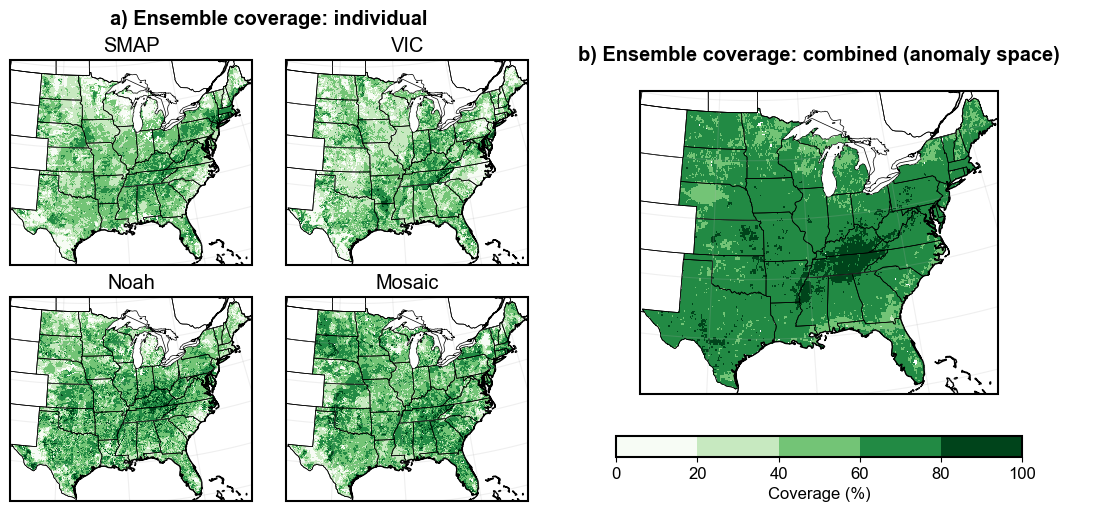

In [8]:
#################
# MAP PLOT
#################
subset_name = 'eCONUS'
save_name = 'best_only'
hindcast_dir = 'best_only'

fig = plt.figure(layout='constrained', figsize=(11, 5))
subfigs = fig.subfigures(1, 2, wspace=0.)

axsLeft = subfigs[0].subplots(2, 2, sharex=True, sharey=True,
                              gridspec_kw=dict(wspace=0.02, hspace=0.02),
                              subplot_kw=dict(projection=ccrs.LambertConformal()))

subfigs[0].suptitle('a) Ensemble coverage: individual', fontweight='bold')

axRight = subfigs[1].subplots(subplot_kw=dict(projection=ccrs.LambertConformal()))
axRight.axis('off')

axRightins = axRight.inset_axes(bounds=[0.1, 0.1, 0.8, 0.8],
                                projection=ccrs.LambertConformal())
subfigs[1].suptitle('b) Ensemble coverage: combined (anomaly space)', fontweight='bold', y=0.92)

###############
# Individual
###############
axs = axsLeft.flatten()

for ido, obs_name in enumerate(obs_names):
    # Read
    ds_coverage = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/hindcasts/{hindcast_dir}/stats/coverage_{save_name}.nc")
    ax = axs[ido]
    # Plot
    p = ds_coverage['coverage'].plot(ax=ax, vmin=0, vmax=100,
                                     cmap = 'Greens', levels=6,
                                     add_colorbar=False,
                                     transform=ccrs.PlateCarree())
    ax.set_title(obs_names_plot[obs_name])
    # Tidy
    ax.coastlines()
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
    ax.set_extent([-106, -73.5, 25, 49], ccrs.Geodetic())

for ax in axs:
    ax.gridlines(draw_labels=False, x_inline=False, rotate_labels=False, alpha=0.2)

# Cbar
# fig.colorbar(p,
#              orientation="horizontal",
#             label="Ensemble Coverage (%)",
#             ax=axs, pad=0.04, shrink=0.5)

###############
# Combined
###############
ax = axRightins

# Read
ds_coverage = xr.open_dataset(f"{project_data_path}/WBM/calibration/{subset_name}/combined/ubcoverage_combined_{save_name}.nc")

# Plot
p = ds_coverage['coverage'].plot(ax=ax, vmin=0, vmax=100,
                                cmap = 'Greens', levels=6,
                                add_colorbar=False,
                                transform=ccrs.PlateCarree())

# Tidy
ax.coastlines()
ax.gridlines(draw_labels=False, x_inline=False, rotate_labels=False, alpha=0.2)
ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
ax.set_extent([-106, -73.5, 25, 49], ccrs.Geodetic())
ax.set_title('')

# Cbar
fig.colorbar(p,
             orientation="horizontal",
             label="Coverage (%)",
             ax=axRight, pad=0.01, shrink=0.75)

plt.savefig('../figs/main/fig6_map_coverage.png', dpi=600, bbox_inches='tight')

## Params

In [28]:
# Load all
subset_name = 'eCONUS'
loss_metric = 'pred_loss'
best_metric = True

metrics_include = ['kge', 'nse', 'taylor',
                   'rmse', 'ubrmse',
                   'mae', 'ubmae', 
                   'mse', 'ubmse',
                   'outer20rmse', 'outer20ubrmse',
                   'outer50rmse', 'outer50ubrmse']

df_all = []
for obs_name in obs_names:
    df_tmp = get_training_res(subset_name, obs_name, loss_metric, metrics_include, best_metric)
    df_tmp['obs_name'] = obs_name
    df_all.append(df_tmp)

df_all = pd.concat(df_all)

In [44]:
# What fraction of best parameters comes from initializing at prior guess?
np.sum(df_all['param_id'] == '00r')

np.int64(28)

In [30]:
# Read covariate inputs
ds_siltfrac = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/siltfrac_NLDASgrid.nc")
ds_sandfrac = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/sandfrac_NLDASgrid.nc")
ds_clayfrac = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/clayfrac_NLDASgrid.nc")

ds_elev = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/NLDAS_elev_STD_NLDASgrid.nc")

ds_land = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/CDL-NLDAS_landtypes_NLDASgrid.nc")

ds_lai = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/LAI_GLDAS_clima_NLDASgrid.nc")

In [31]:
# Read awCap and wiltingp
ds_awCap_obs = []
ds_wiltingp_obs = []

for obs_name in obs_names:
    awCap = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/{obs_name}_awCap.nc")
    awCap = awCap.expand_dims({'obs_name':[obs_name]})
    ds_awCap_obs.append(awCap)
    
    wiltingp = xr.open_dataset(f"{project_data_path}/WBM/geo_inputs/{obs_name}_wiltingp.nc")
    wiltingp = wiltingp.expand_dims({'obs_name':[obs_name]})
    ds_wiltingp_obs.append(wiltingp)
    
ds_awCap_obs = xr.combine_by_coords(ds_awCap_obs, coords='minimal')
ds_wiltingp_obs = xr.combine_by_coords(ds_wiltingp_obs, coords='minimal')

In [7]:
##############################
# Construct parameter maps
# if not done already
##############################
if not os.path.exists(f"{project_data_path}/WBM/calibration/eCONUS/param_maps/param_map.nc"):
    ds_alpha = []
    ds_betaHBV = []
    ds_awCap = []
    ds_wiltingp = []
    ds_Kpet = []

    for obs_name in obs_names:
        for metric in metrics_include:
            # Select params
            df_sel = df_all[(df_all['obs_name'] == obs_name) & (df_all['metric'] == metric)]
            
            # Alpha
            alpha = (
                1. + 
                np.exp(df_sel['alpha_siltcoef'].iloc[0]) * ds_siltfrac['siltfrac']/100. + 
                np.exp(df_sel['alpha_sandcoef'].iloc[0]) * ds_sandfrac['sandfrac']/100. + 
                np.exp(df_sel['alpha_claycoef'].iloc[0]) * ds_clayfrac['clayfrac']/100.)
            
            alpha = alpha.expand_dims({'obs_name':[obs_name], 'metric':[metric]})
            ds_alpha.append(alpha)
            
            # Beta
            betaHBV = (
                1. + 
                np.exp(df_sel['betaHBV_siltcoef'].iloc[0]) * ds_siltfrac['siltfrac']/100. + 
                np.exp(df_sel['betaHBV_sandcoef'].iloc[0]) * ds_sandfrac['sandfrac']/100. + 
                np.exp(df_sel['betaHBV_claycoef'].iloc[0]) * ds_clayfrac['clayfrac']/100. + 
                np.exp(df_sel['betaHBV_elevcoef'].iloc[0]) * ds_elev['NLDAS_elev_std']/100.)
            
            betaHBV = betaHBV.expand_dims({'obs_name':[obs_name], 'metric':[metric]})
            ds_betaHBV.append(betaHBV)
            
            # awCap
            awCap = np.exp(df_sel['awCap_scalar'].iloc[0]) * ds_awCap_obs['awCap'].sel(obs_name=obs_name)
            awCap = awCap.expand_dims({'obs_name':[obs_name], 'metric':[metric]})
            ds_awCap.append(awCap)
            
            # wiltingp
            wiltingp = np.exp(df_sel['wiltingp_scalar'].iloc[0]) * ds_wiltingp_obs['wiltingp'].sel(obs_name=obs_name)
            wiltingp = wiltingp.expand_dims({'obs_name':[obs_name], 'metric':[metric]})
            ds_wiltingp.append(wiltingp)
            
            # Kpet
            Kpet = construct_Kpet_map(df_sel, ds_land, ds_lai)
            Kpet = Kpet.expand_dims({'obs_name':[obs_name], 'metric':[metric]})
            ds_Kpet.append(Kpet)
        
    # Combine and store all time-invariant parameters
    ds_params_all = xr.merge([
        xr.combine_by_coords(ds_awCap),
        xr.combine_by_coords(ds_wiltingp), 
        xr.Dataset({
            'alpha': xr.combine_by_coords(ds_alpha),
            'beta_R': xr.combine_by_coords(ds_betaHBV)
        }),
    ]).drop_vars(["time", "depth"])

    ds_params_all.to_netcdf(f"{project_data_path}/WBM/calibration/eCONUS/param_maps/param_map.nc")
    
    # Combine and store Kpet
    ds_Kpet = xr.combine_by_coords(ds_Kpet)
    ds_Kpet.to_netcdf(f"{project_data_path}/WBM/calibration/eCONUS/param_maps/Kpet.nc")

In [ ]:
####################
# Param map figure
####################
ds_params_all = xr.open_dataset(f"{project_data_path}/WBM/calibration/eCONUS/param_maps/param_map.nc")
ds_params_all = _subset_states(ds_params_all, subsets['eCONUS']) # subset to eCONUS

/storage/home/dcl5300/miniforge3/envs/climate-stack-2024-10/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/home/dcl5300/miniforge3/envs/climate-stack-2024-10/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/home/dcl5300/miniforge3/envs/climate-stack-2024-10/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/home/dcl5300/miniforge3/envs/climate-stack-2024-10/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/storage/home/dcl5300/miniforge3/envs/cl

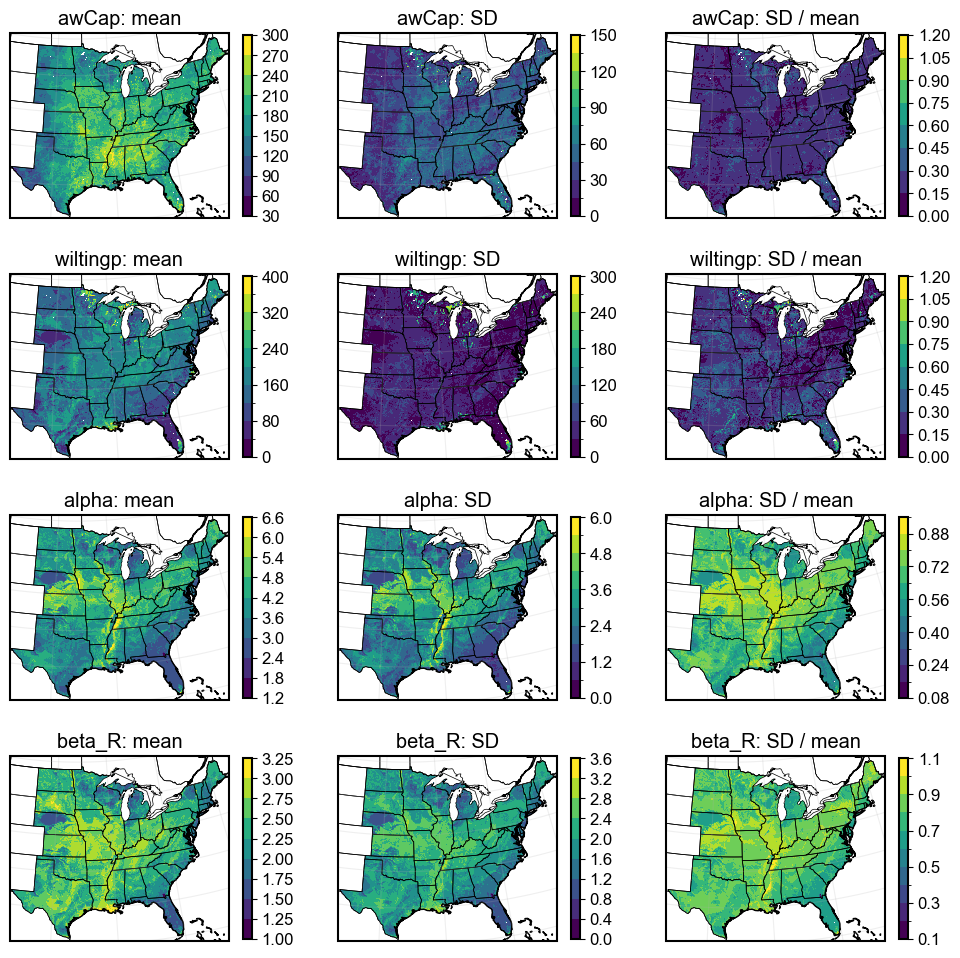

In [29]:
# Plot
fig, axs = plt.subplots(4,3, figsize=(12,12), subplot_kw=dict(projection=ccrs.LambertConformal()))

cbar_kwargs = {'shrink':0.9, 'label':''}
sc_cmap = 'viridis'

for ip, param in enumerate(list(ds_params_all.keys())):
    # Mean
    ax=axs[ip,0]
    ds_params_all[param].mean(dim=['obs_name', 'metric']).plot(ax=ax, transform=ccrs.PlateCarree(), levels=11, cmap=sc_cmap, cbar_kwargs=cbar_kwargs)
    ax.set_title(f"{param}: mean")
    
    # SD
    ax=axs[ip,1]
    ds_params_all[param].std(dim=['obs_name', 'metric']).plot(ax=ax, transform=ccrs.PlateCarree(), levels=11, cmap=sc_cmap, cbar_kwargs=cbar_kwargs)
    ax.set_title(f"{param}: SD")
    
    # CV
    ax=axs[ip,2]
    (ds_params_all[param].std(dim=['obs_name', 'metric'])/
     ds_params_all[param].mean(dim=['obs_name', 'metric'])).plot(ax=ax, transform=ccrs.PlateCarree(), levels=11, cmap=sc_cmap, cbar_kwargs=cbar_kwargs)
    ax.set_title(f"{param}: SD / mean")
    
for ax in axs.flatten():
    # Tidy
    ax.coastlines()
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5)
    ax.add_feature(cfeature.BORDERS, edgecolor='black', linewidth=0.5)
    ax.set_extent([-106, -73.5, 25, 49], ccrs.Geodetic())
    ax.gridlines(draw_labels=False, x_inline=False, rotate_labels=False, alpha=0.2)

plt.savefig('../figs/si/param_maps.png', dpi=600, bbox_inches='tight')

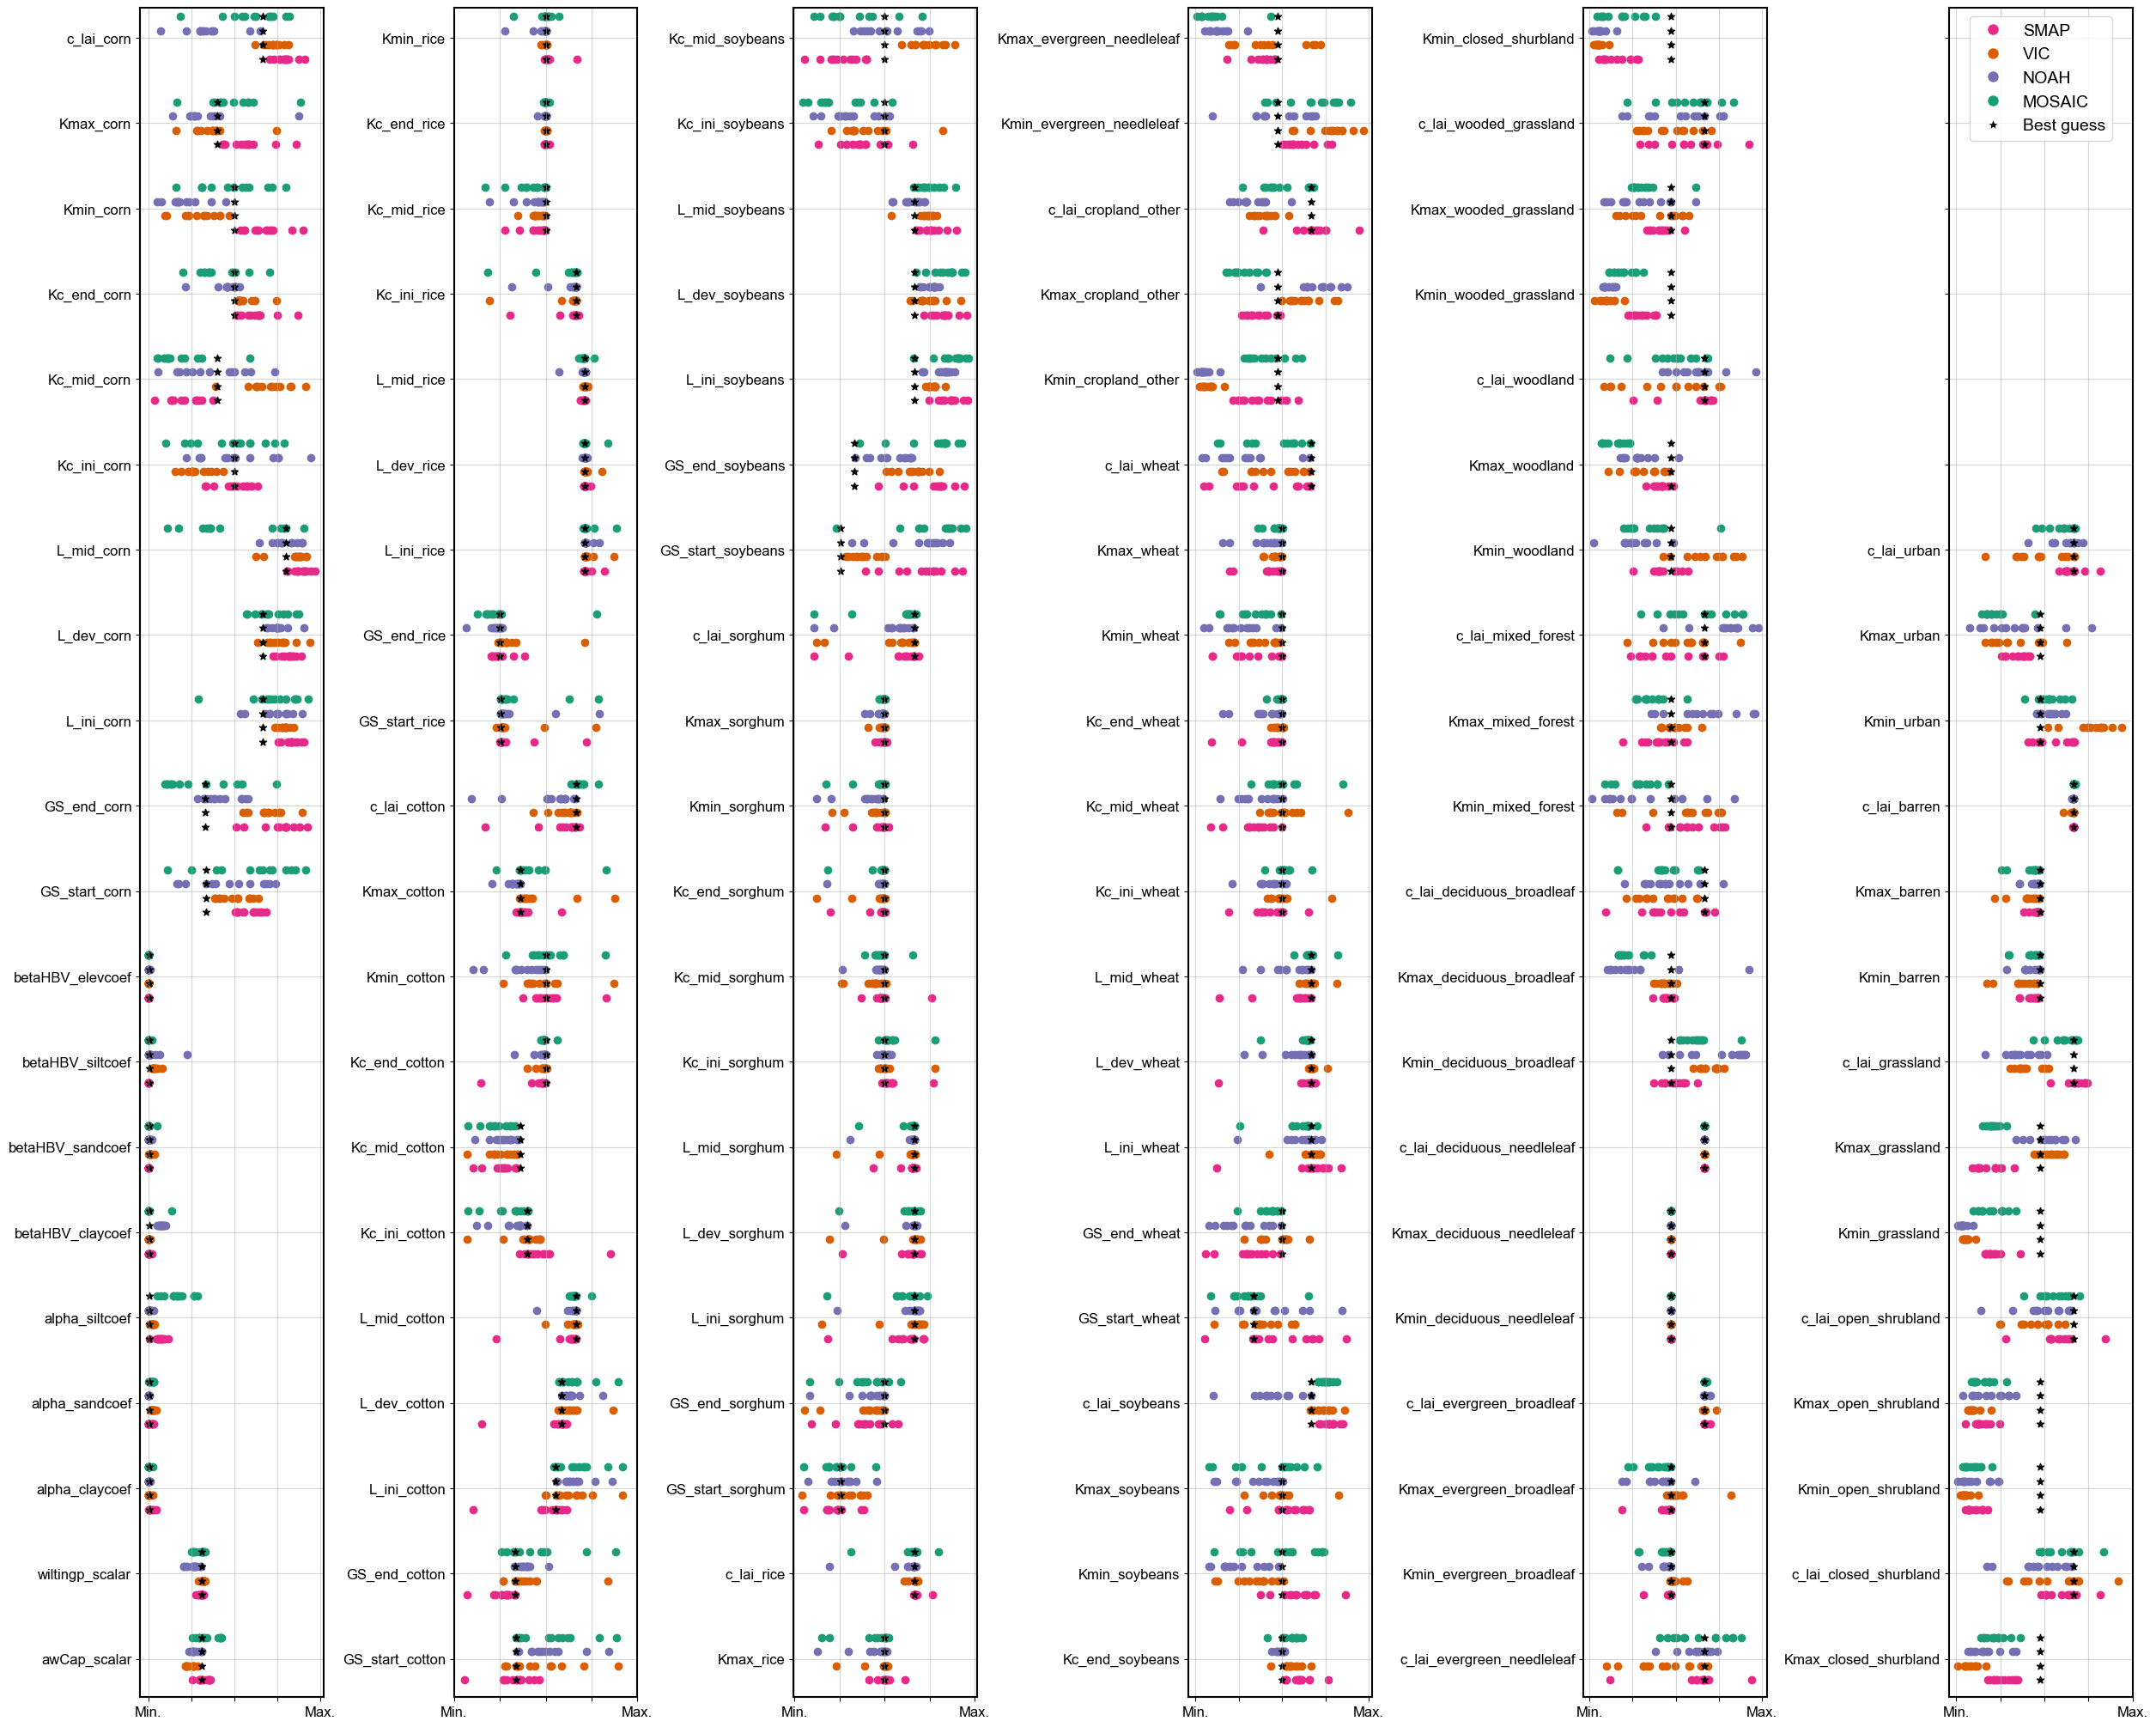

In [32]:
#############################
# Calibrated params: range
#############################
fig, axs = plt.subplots(1,6, figsize=(25,20), layout='constrained')

# Loop through all params
for idp, param in enumerate(param_names):
    # Column counter
    idcol = idp // 20
    ax = axs[idcol]
    for ido, obs_name in enumerate(obs_names):
        # Select data
        df_obs_sel = df_all[df_all['obs_name'] == obs_name]
        # Scale
        param_scaled = (np.exp(df_obs_sel[param]) - np.exp(params_lower[idp])) / (np.exp(params_upper[idp]) - np.exp(params_lower[idp]))
        param_initial_scaled = (np.exp(initial_params[idp]) - np.exp(params_lower[idp])) / (np.exp(params_upper[idp]) - np.exp(params_lower[idp]))
        # Plot
        ax.scatter(x=param_scaled, y=[(idp % 20) + (ido/6)]*len(df_obs_sel), color=obs_colors[obs_name], marker='o')
        ax.scatter(x=param_initial_scaled, y=[(idp % 20) + (ido/6)], color='black', marker='*')
    # Correct labels
    if idcol == 5:
        ax.set_yticks(ticks=np.arange(20)+1.5/6,
                      labels=param_names[-14:] + [""]*6) 
    else:
        ax.set_yticks(ticks=np.arange(20)+1.5/6,
                  labels=param_names[(20*idcol):(20*(idcol+1))])

for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_ylim([-0.2,19.6])
    ax.set_xticks(ticks=[0., 0.25, 0.5, 0.75, 1.], labels=["Min.", "", "", "", "Max."])

custom_lines = [Line2D([0], [0], color='w', markerfacecolor=obs_colors['SMAP'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['VIC'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['NOAH'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['MOSAIC'], marker='o', markersize=10),
                   Line2D([0], [0], color='w', markerfacecolor='black', marker='*', markersize=10)]
axs[-1].legend(custom_lines, obs_names + ['Best guess'],
                ncols=1, fontsize=14, loc='upper center')
    
plt.savefig('../figs/si/param_posteriors_minmax.pdf', bbox_inches='tight')

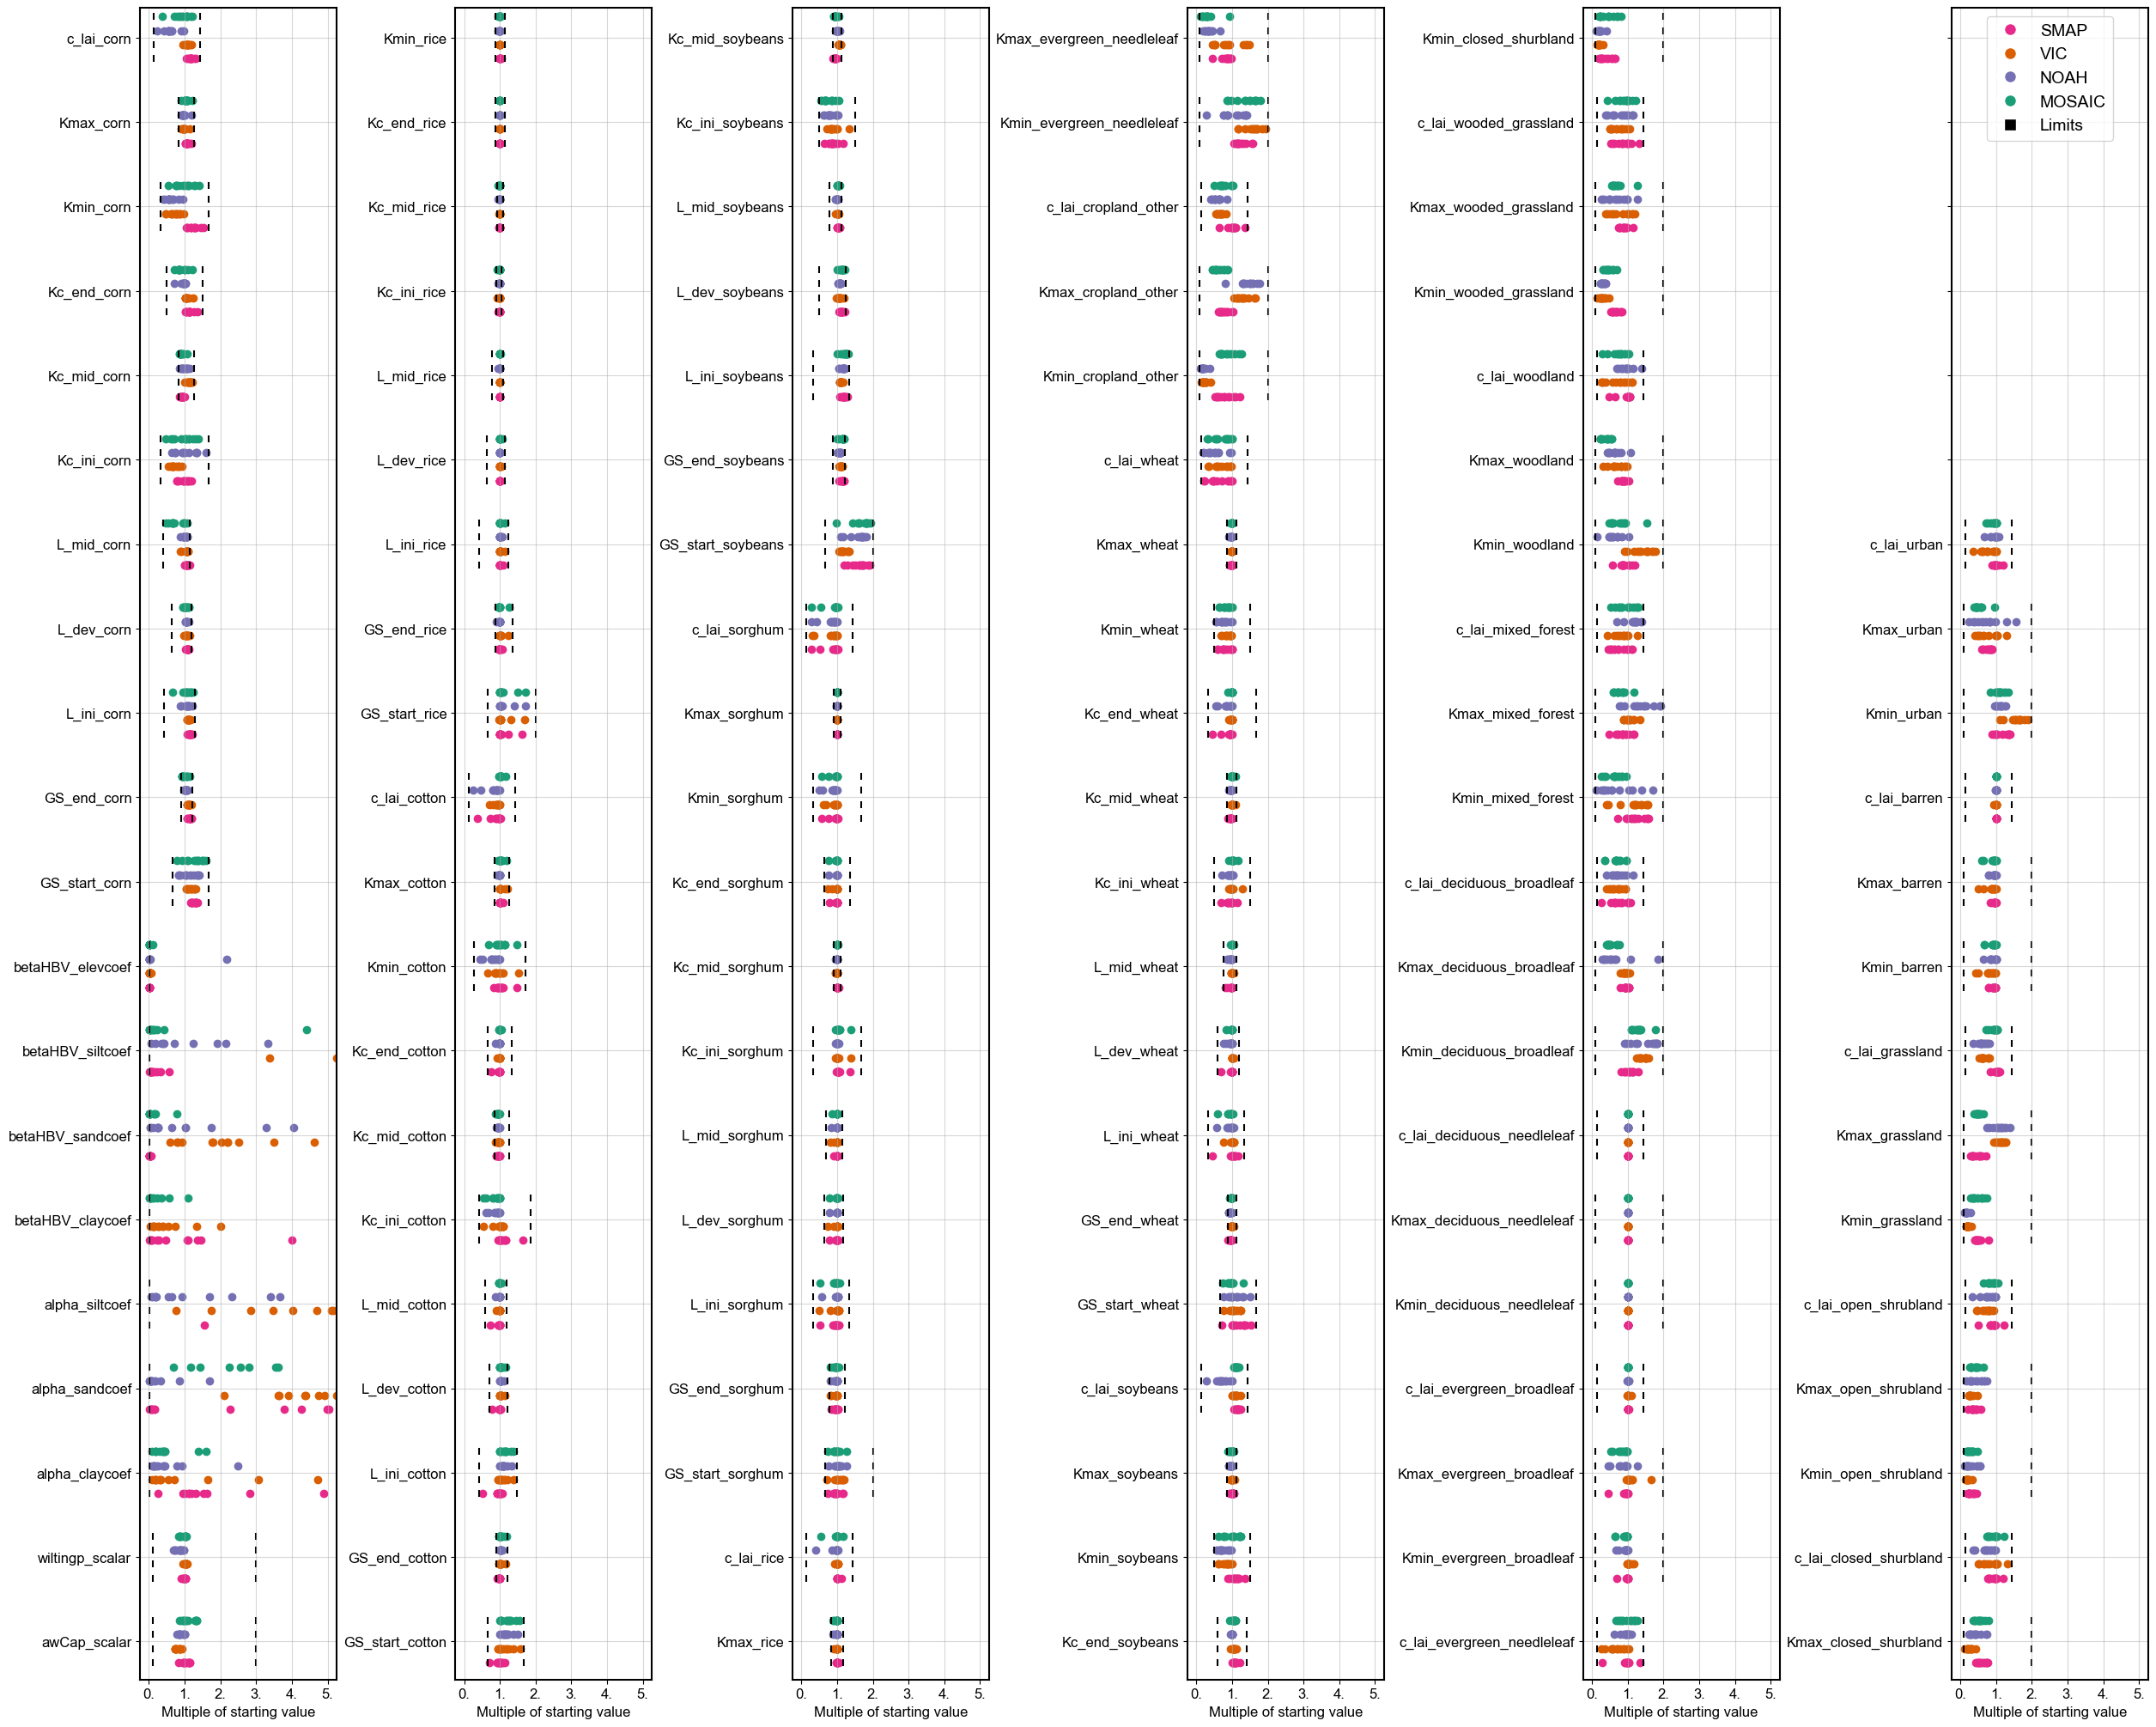

In [33]:
######################################
# Calibrated params: starting value
######################################
fig, axs = plt.subplots(1,6, figsize=(25,20), layout='constrained')

# Loop through all params
for idp, param in enumerate(param_names):
    # Column counter
    idcol = idp // 20
    ax = axs[idcol]
    for ido, obs_name in enumerate(obs_names):
        # Select data
        df_obs_sel = df_all[df_all['obs_name'] == obs_name]
        # Scale
        param_scaled = np.exp(df_obs_sel[param]) / np.exp(initial_params[idp])
        param_upper = np.exp(params_upper[idp])/ np.exp(initial_params[idp])
        param_lower = np.exp(params_lower[idp])/ np.exp(initial_params[idp])
        # Plot
        ax.scatter(x=param_scaled, y=[(idp % 20) + (ido/6)]*len(df_obs_sel), color=obs_colors[obs_name], marker='o')
        ax.scatter(x=param_upper, y=[(idp % 20) + (ido/6)], color='black', marker='|')
        ax.scatter(x=param_lower, y=[(idp % 20) + (ido/6)], color='black', marker='|')
    # Correct labels
    if idcol == 5:
        ax.set_yticks(ticks=np.arange(20)+1.5/6,
                      labels=param_names[-14:] + [""]*6) 
    else:
        ax.set_yticks(ticks=np.arange(20)+1.5/6,
                  labels=param_names[(20*idcol):(20*(idcol+1))])

for ax in axs:
    ax.grid(alpha=0.5)
    ax.set_ylim([-0.2,19.6])
    ax.set_xticks(ticks=[0., 1., 2., 3., 4., 5.], labels=["0.", "1.", "2.", "3.", "4.", "5."])
    ax.set_xlim([-0.25,5.25])
    ax.set_xlabel('Multiple of starting value')

custom_lines = [Line2D([0], [0], color='w', markerfacecolor=obs_colors['SMAP'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['VIC'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['NOAH'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor=obs_colors['MOSAIC'], marker='o', markersize=10),
                    Line2D([0], [0], color='w', markerfacecolor='black', marker='s', markersize=10)]
axs[-1].legend(custom_lines, obs_names + ['Limits'],
                ncols=1, fontsize=14, loc='upper center')
    
plt.savefig('../figs/si/param_posteriors_ratio.pdf', bbox_inches='tight')

## Loss functions

In [91]:
def get_training_res(
    subset_name, obs_name, loss_metric, metrics_include, best_loss
):
    """
    Reads the training results
    """
    # Loop through files
    files = glob(
        f"{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/training_res/*.txt"
    )

    df_out = []
    for file in files:
        # Read
        df = pd.read_csv(file, sep=" ").dropna(how="any")
        df["epoch"] = df["epoch"].astype(np.float32)

        # Add identifiers
        _, param_id, val_id, _ = file.split("/")[-1].split("_")
        df["param_id"] = param_id
        df["val_id"] = val_id
        
        # Take best
        df_best = df.query("epoch > 10").sort_values(by=loss_metric).iloc[:1]
        if len(df_best) > 0:
            df_out.append(df_best)

    # Join
    df_out = pd.concat(df_out).reset_index().drop(columns="index")

    # Filter best result for each metric
    if best_loss:
        metric_min_inds = df_out.groupby("metric")[loss_metric].idxmin()
        df_out = (
            df_out.loc[metric_min_inds].reset_index().drop(columns="index")
        )

    # Subset metrics
    if metrics_include != "all":
        df_out = df_out[df_out["metric"].isin(metrics_include)]

    # Return
    return df_out

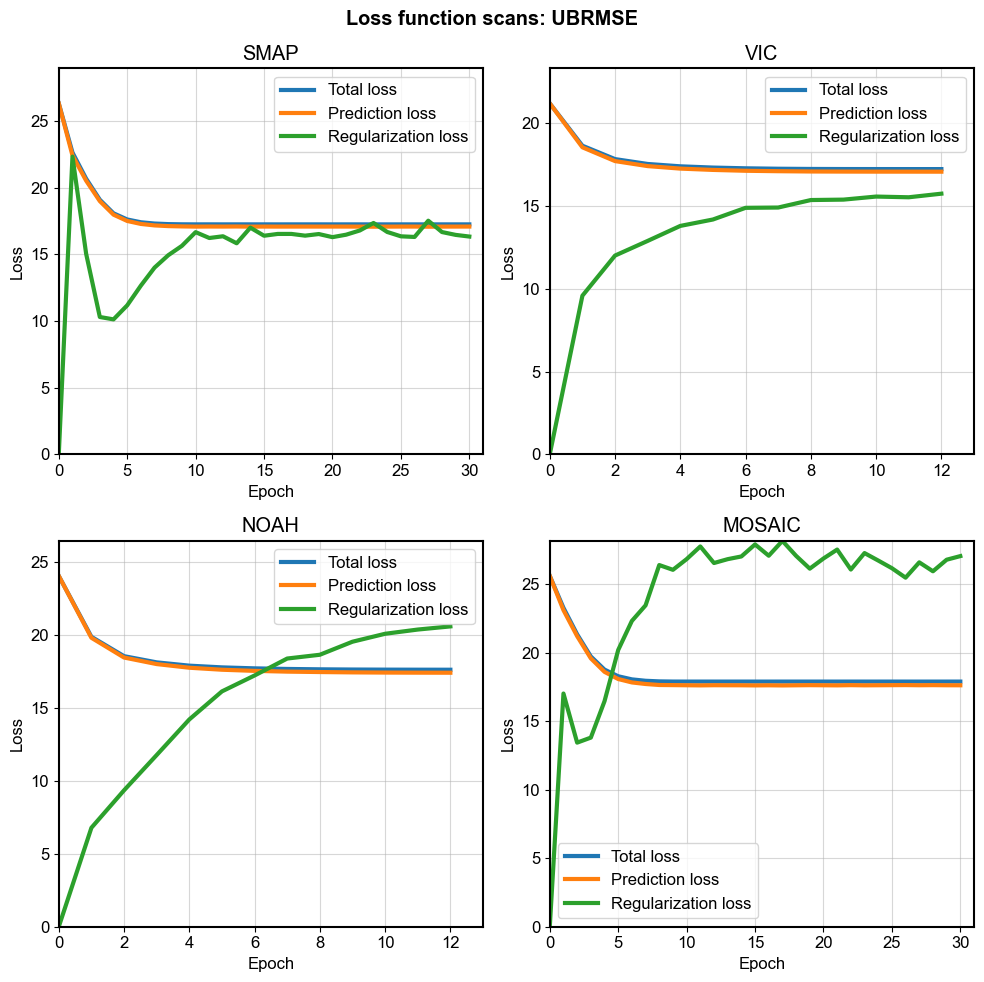

In [103]:
# Plot all best fit loss functions (best fit same as projections)
subset_name = "eCONUS"
loss_metric = "pred_loss"

metrics_include = ["ubrmse"]
metric = metrics_include[0]

best_loss = True

fig, axs = plt.subplots(2,2, figsize=(10,10))
axs = axs.flatten()

fig.suptitle(f"Loss function scans: {metric.upper()}", fontweight='bold')

# Get for all obs
for ido, obs_name in enumerate(obs_names):
    ax = axs[ido]
    # Get best fit
    param_id = get_training_res(subset_name, obs_name, loss_metric, metrics_include, best_loss)['param_id'].values[0]
    
    # Read best fit
    file = glob(f'{project_data_path}/WBM/calibration/{subset_name}/{obs_name}/training_res/{metric}_{param_id}*.txt')[0]
    df = pd.read_csv(file, sep=" ")
    
    # Plot
    df.plot(y='train_loss', x='epoch', ax=ax, label = 'Total loss', lw=3)
    df.plot(y='pred_loss', x='epoch', ax=ax, label = 'Prediction loss', lw=3)
    df.plot(y='reg_loss', x='epoch', ax=ax, label = 'Regularization loss', lw=3)
    
    # Tidy
    ax.set_ylabel('Loss')
    ax.set_xlabel('Epoch')
    ax.grid(alpha=0.5)
    ax.set_ylim([0, df['pred_loss'].max()*1.1])
    ax.set_xlim([0, df['epoch'].max()+1])
    ax.set_title(obs_name)

plt.tight_layout()
plt.savefig(f'../figs/si/loss_example_{metric}.pdf', dpi=600, bbox_inches='tight')